In [2]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
# data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\C\raw_data.csv")

cols = data.columns[:-1].to_list() 

whole = data.copy()

data = whole.iloc[0:700,:]

# data[cols] = (data[cols] - data[cols].mean()) / data[cols].std() # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

validation = whole.iloc[700:1000,:]

# validation[cols] = (validation[cols] - validation[cols].mean()) / validation[cols].std()

# ### 先用傳統統計模型驗證
X = data[cols]

# XTX = X.T @ X

y = data["Y"]

In [ ]:
# pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

def train_attention_model(X, y, epochs=1000, lr=0.001):

    if isinstance(X, pd.DataFrame): 
        X = torch.tensor(
            X.values,
            dtype=torch.float32
        )

    if isinstance(y, pd.Series):
        y = torch.tensor(
            y.values,
            dtype=torch.float32
        )

    N = X.shape[0]
    P = X.shape[1]

    y = y.reshape(-1, 1)

    X_Y_train = torch.cat(
        (X, y),
        dim=1
    )

    X_Y_features = X_Y_train.t()

    dk = 32

    d_k = 32
    W_Q = nn.Linear(
        X_Y_features.shape[1],
        d_k,
        bias=False
    )

    W_K = nn.Linear(
        X_Y_features.shape[1],
        d_k,
        bias=False
    )


    optimizer = torch.optim.Adam(
        list(W_Q.parameters()) +
        list(W_K.parameters()), 

        lr=lr

    )


    lam = 1

    # Deep GLM 
    p = X.shape[1]

    I = torch.eye(
        p,
        dtype=X.dtype,
        device=X.device
    )


    for epoch in range(epochs):

        Q = W_Q(X_Y_features)
        
        K = W_K(X_Y_features)

        scores = torch.matmul(
            Q,
            K.transpose(-2,-1)
        ) 

        scores = scores / np.sqrt(dk)

        attention_matrix = F.softmax(
            scores / (d_k ** 0.5),
            dim=-1
        )

        # 把Y再從矩陣中拿掉
        A = attention_matrix[:-1,:-1]

        # 矩陣乘上Y的變異數
        var_y = torch.var(y)

        A_var_y = A * var_y


        # beta
        beta = torch.linalg.solve(
            X.T @ X + A + I*torch.trace(A),
            X.T @ y
        )


        y_hat = X@beta


        loss = F.mse_loss(
            y_hat,
            y
        )


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():

        Q = W_Q(X_Y_features)
        
        K = W_K(X_Y_features)

        scores = torch.matmul(
            Q,
            K.transpose(-2,-1)
        ) 

        scores = scores / np.sqrt(dk)

        attention_matrix = F.softmax(
            scores / (d_k ** 0.5),
            dim=-1
        )

        # 把Y再從矩陣中拿掉
        A = attention_matrix[:-1,:-1]

        final_attn = A.clone()

        # 矩陣乘上Y的變異數
        var_y = torch.var(y)

        A_var_y = A * var_y


        # beta
        final_beta = torch.linalg.solve(
            X.T @ X + A + I*torch.trace(A),
            X.T @ y
        )

        # adaptive
        adaptive_matrix = A + I*torch.trace(A)


    return (
        final_beta.detach(),
        final_attn.detach(),
        adaptive_matrix.detach()
    )

In [4]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from tqdm import tqdm

n_repeat = 100

beta_results = []
mse_results = []
rmse_results = []
r2_results = []
attention_results = []
adaptive_results = []

for seed in tqdm(range(n_repeat), desc="Simulation"):

    torch.manual_seed(seed)
    np.random.seed(seed)


    beta_attn, attn_matrix, adaptive_matrix = train_attention_model(
        X,
        y
    )


    beta_results.append(
        beta_attn.numpy()
    )

    attention_results.append(
        attn_matrix.numpy()
    )

    adaptive_results.append(
    adaptive_matrix.numpy()
    )


    # validation

    X_val = validation[cols].values

    y_pred = (
        torch.tensor(
            X_val,
            dtype=torch.float32
        )
        @ beta_attn
    ).numpy()

    y_val = validation["Y"].values

    mse = mean_squared_error(
        y_val,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_val,
        y_pred
    )


    mse_results.append(mse)
    rmse_results.append(rmse)
    r2_results.append(r2)

Simulation: 100%|██████████| 100/100 [03:08<00:00,  1.89s/it]


In [5]:
beta_results = np.array(beta_results)

beta_mean = beta_results.mean(axis=0)

beta_sd = beta_results.std(axis=0)

In [6]:
# 用套件驗證OLS
import statsmodels.api as sm

X = data[cols]

model = sm.OLS(
    data["Y"],
    X          # 不加 constant
)

result = model.fit()

beta_ols = result.params.values

y_pred_ols = X_val @ beta_ols

mse_ols = mean_squared_error(
    y_val,
    y_pred_ols
)

rmse_ols = np.sqrt(mse_ols)

ols_r2 = r2_score(y_val, y_pred_ols)

In [7]:
# Ridge
from sklearn.linear_model import Ridge
# ======================
# Split X and Y
# ======================

X_train = data[cols].values
y_train = data["Y"].values

# ======================
# Ridge model
# ======================

ridge = Ridge(alpha=1.0, fit_intercept=False)

ridge.fit(
    X_train,
    y_train,
)

beta_ridge = ridge.coef_

y_pred_ridge = X_val @ beta_ridge

mse_ridge = mean_squared_error(
    y_val,
    y_pred_ridge
)

rmse_ridge = np.sqrt(mse_ridge)

ridge_r2 = r2_score(y_val, y_pred_ridge)

In [12]:
# 模擬資料生成時的實際係數
true_beta = pd.read_csv(
    r"C:\Users\USER\Desktop\碩論\程式碼\C\true_beta.csv"
)

beta_true = true_beta["True_Coefficient"].values
ols_bias = abs(beta_ols - beta_true)
attn_bias = abs(beta_mean.flatten() - beta_true) # 平均係數
ridge_bias = abs(beta_ridge - beta_true)

In [14]:
beta_summary = pd.DataFrame({

    "Beta_mean(DeepGLM)":beta_mean.flatten(),

    "Beta_SD(DeepGLM)":beta_sd.flatten(),

    "OLS":result.params,

    "Ridge":beta_ridge,

    "Simulation": beta_true

})


print(beta_summary)
print(f"OLS的係數偏差:{ols_bias.sum():.6f}")
print(f"Ridge的係數偏差:{ridge_bias.sum():.6f}")
print(f"DeepGLM的平均係數偏差:{attn_bias.sum():.6f}")

           Beta_mean(DeepGLM)  Beta_SD(DeepGLM)       OLS     Ridge  \
Intercept            1.932738      2.174222e-06  1.932738  1.929794   
X1                   1.984512      1.242524e-06  1.984513  1.981674   
X2                  -1.459541      1.694827e-06 -1.459544 -1.457278   
X3                   0.522877      5.087737e-07  0.522878  0.522690   
X4                  -0.132968      1.344907e-07 -0.132968 -0.132743   
X5                   3.017041      1.238859e-06  3.017042  3.012712   
X6                   0.004333      1.430737e-07  0.004333  0.004400   
X7                  -0.049727      9.043789e-08 -0.049727 -0.049651   
X8                  -0.059095      9.024203e-08 -0.059095 -0.059340   
X9                  -0.039714      6.863335e-08 -0.039714 -0.039510   
X10                  0.013323      6.540305e-08  0.013323  0.013375   

           Simulation  
Intercept         1.0  
X1                2.0  
X2               -1.5  
X3                0.5  
X4                0.0  
X5 

In [15]:
metric_summary = pd.DataFrame({

    "Metric":[
        "MSE",
        "RMSE",
        "R2",
    ],

    "Mean(DeepGLM)":[
        np.mean(mse_results),
        np.mean(rmse_results),
        np.mean(r2_results)
    ],

    "SD(DeepGLM)":[
        np.std(mse_results),
        np.std(rmse_results),
        np.std(r2_results)
    ],

    "OLS":[
        mse_ols,
        rmse_ols,
        ols_r2
    ],

    "Ridge":[
        mse_ridge,
        rmse_ridge,
        ridge_r2
    ]

})


print(metric_summary)

  Metric  Mean(DeepGLM)   SD(DeepGLM)       OLS     Ridge
0    MSE       3.850519  9.463343e-07  3.850518  3.850267
1   RMSE       1.962274  2.411320e-07  1.962274  1.962210
2     R2       0.796702  4.996417e-08  0.796702  0.796715


In [18]:
attention_results = np.array(attention_results)

attention_mean = attention_results.mean(axis=0)

attention_sd = attention_results.std(axis=0)

attention_summary = pd.DataFrame(
    index=cols,
    columns=cols
)

for i in range(len(cols)):
    for j in range(len(cols)):

        attention_summary.iloc[i,j] = (
            f"{attention_mean[i,j]:.4f}"
            " ± "
            f"{attention_sd[i,j]:.4f}"
        )

print(attention_summary)

                 Intercept               X1               X2               X3  \
Intercept  0.0001 ± 0.0003  0.0067 ± 0.0109  0.0095 ± 0.0180  0.0194 ± 0.0303   
X1         0.0115 ± 0.0095  0.0003 ± 0.0003  0.0146 ± 0.0125  0.0251 ± 0.0263   
X2         0.0000 ± 0.0000  0.0000 ± 0.0000  0.0000 ± 0.0000  0.0000 ± 0.0000   
X3         0.0105 ± 0.0126  0.0084 ± 0.0113  0.0218 ± 0.0275  0.0004 ± 0.0006   
X4         0.0010 ± 0.0045  0.0003 ± 0.0017  0.0023 ± 0.0097  0.0022 ± 0.0114   
X5         0.0121 ± 0.0083  0.0065 ± 0.0058  0.0135 ± 0.0126  0.0234 ± 0.0214   
X6         0.0004 ± 0.0019  0.0009 ± 0.0035  0.0018 ± 0.0071  0.0064 ± 0.0234   
X7         0.0013 ± 0.0053  0.0015 ± 0.0055  0.0039 ± 0.0164  0.0062 ± 0.0229   
X8         0.0005 ± 0.0030  0.0001 ± 0.0006  0.0009 ± 0.0058  0.0009 ± 0.0061   
X9         0.0000 ± 0.0000  0.0000 ± 0.0000  0.0000 ± 0.0000  0.0000 ± 0.0000   
X10        0.0007 ± 0.0041  0.0010 ± 0.0063  0.0024 ± 0.0143  0.0010 ± 0.0059   

                        X4 

In [19]:
adaptive_results = np.array(adaptive_results)

adaptive_mean = adaptive_results.mean(axis=0)

adaptive_sd = adaptive_results.std(axis=0)

adaptive_summary = pd.DataFrame(
    index=cols,
    columns=cols
)

for i in range(len(cols)):
    for j in range(len(cols)):
        adaptive_summary.iloc[i,j] = (
            f"{adaptive_mean[i,j]:.4f}"
            " ± "
            f"{adaptive_sd[i,j]:.4f}"
        )

print(adaptive_summary)

                 Intercept               X1               X2               X3  \
Intercept  0.0013 ± 0.0009  0.0067 ± 0.0109  0.0095 ± 0.0180  0.0194 ± 0.0303   
X1         0.0115 ± 0.0095  0.0014 ± 0.0009  0.0146 ± 0.0125  0.0251 ± 0.0263   
X2         0.0000 ± 0.0000  0.0000 ± 0.0000  0.0012 ± 0.0008  0.0000 ± 0.0000   
X3         0.0105 ± 0.0126  0.0084 ± 0.0113  0.0218 ± 0.0275  0.0016 ± 0.0013   
X4         0.0010 ± 0.0045  0.0003 ± 0.0017  0.0023 ± 0.0097  0.0022 ± 0.0114   
X5         0.0121 ± 0.0083  0.0065 ± 0.0058  0.0135 ± 0.0126  0.0234 ± 0.0214   
X6         0.0004 ± 0.0019  0.0009 ± 0.0035  0.0018 ± 0.0071  0.0064 ± 0.0234   
X7         0.0013 ± 0.0053  0.0015 ± 0.0055  0.0039 ± 0.0164  0.0062 ± 0.0229   
X8         0.0005 ± 0.0030  0.0001 ± 0.0006  0.0009 ± 0.0058  0.0009 ± 0.0061   
X9         0.0000 ± 0.0000  0.0000 ± 0.0000  0.0000 ± 0.0000  0.0000 ± 0.0000   
X10        0.0007 ± 0.0041  0.0010 ± 0.0063  0.0024 ± 0.0143  0.0010 ± 0.0059   

                        X4 

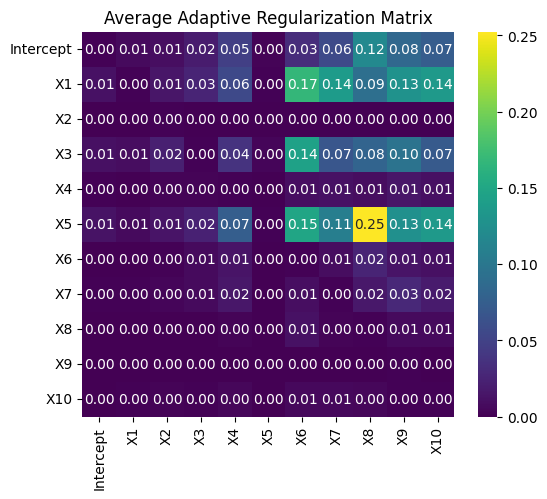

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    adaptive_mean,
    xticklabels=cols,
    yticklabels=cols,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Average Adaptive Regularization Matrix")
plt.show()